<a href="https://colab.research.google.com/github/olueniola1-design/ASSIGNMENT-12-NEURAL-NETWORK-AND-DEEP-LEARNING/blob/main/ASSIGNMENT_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##ASSIGNMENT 12

###NEURAL NETWORK AND DEEP LEARNING BASICS

LINK
https://github.com/olueniola1-design/ASSIGNMENT-12-NEURAL-NETWORK-AND-DEEP-LEARNING/blob/main/ASSIGNMENT_12.ipynb

## Introduction

This notebook demonstrates the development of a simple neural network model for image classification using the Fashion MNIST dataset. The Fashion MNIST dataset is a collection of 70,000 grayscale images of clothing items, categorized into 10 classes. It serves as a direct drop-in replacement for the original MNIST dataset, providing a slightly more challenging benchmark for machine learning algorithms.

The goal is to build a feed-forward neural network that can accurately classify these fashion items. I will cover data loading, preprocessing, model definition, training, evaluation, and a discussion of practical applications and future improvements.

##STEP 1
###IMPORT LIBRARY AND LOAD DATASET

In [1]:
# 1. Import Libraries and Load Dataset
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load the Fashion MNIST dataset recommended in the assignment guidelines
fashion_mnist = datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Define class names for the 10 categories
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"Training data shape: {X_train_full.shape}")
print(f"Test data shape: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


##STEP 2.

###DATA VISUALIZATION

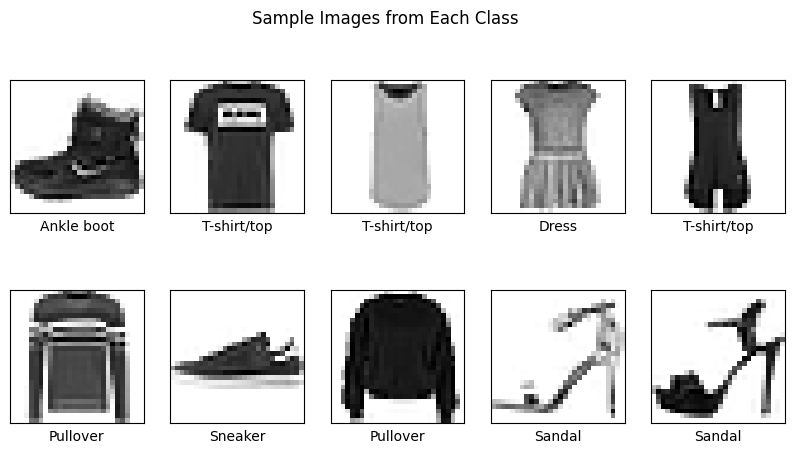

In [2]:
# Data Visualization
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train_full[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train_full[i]])
plt.suptitle("Sample Images from Each Class")
plt.show()

##STEP 3

###DATA PREPROCESSING AND VALIDATION SPLIT

## Methodology

### Data Preprocessing

The dataset is loaded using TensorFlow's built-in `fashion_mnist.load_data()` function, which provides training and test sets. To prepare the image data for the neural network, pixel values are normalized from the range [0, 255] to [0, 1] by dividing by 255.0. This helps in faster convergence during training. A validation set of 5,000 samples is also created from the full training set to monitor model performance during training and prevent overfitting.

### Model Architecture

The neural network architecture is a sequential model consisting of three main layers:
1.  **Flatten Layer**: Converts the 28x28 2D image arrays into a 1D vector of 784 pixels, which can be fed into the dense layers.
2.  **Dense Hidden Layers**: Two fully connected (Dense) layers with ReLU (Rectified Linear Unit) activation functions. The first hidden layer has 256 neurons, and the second has 128 neurons. These layers learn complex patterns from the input data.
3.  **Output Layer**: A Dense layer with 10 neurons (one for each class) and a softmax activation function. Softmax ensures that the output probabilities for each class sum to 1, making it suitable for multi-class classification.

### Training Process

The model is compiled with the `Adam` optimizer, `sparse_categorical_crossentropy` as the loss function (suitable for integer labels), and `accuracy` as the metric. The `fit` method is then used to train the model on the preprocessed training data (`X_train`, `y_train`) for 15 epochs, with a batch size of 64. The validation data (`X_val`, `y_val`) is used to observe the model's performance on unseen data during each epoch.

In [3]:
# Data Preprocessing and Validation Split
# Normalize pixel values to be between 0 and 1
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Create a validation split (using 5,000 samples for validation)
X_val, X_train = X_train_full[:5000], X_train_full[5000:]
y_val, y_train = y_train_full[:5000], y_train_full[5000:]

##STEP 4
### MODEL ARCHITECTURE CONSTRUCTION

In [4]:
# Model Architecture Construction
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),          # Flatten 28x28 images to 1D vector
    layers.Dense(256, activation='relu'),          # Hidden layer with ReLU activation
    layers.Dense(128, activation='relu'),          # Second hidden layer for complexity
    layers.Dense(10, activation='softmax')         # Output layer with Softmax for 10 classes
])

# Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

##STEP 5
### MODEL TRAINING

In [5]:
# Model Training
EPOCHS = 15
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val)
)

Epoch 1/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8240 - loss: 0.4948 - val_accuracy: 0.8500 - val_loss: 0.4131
Epoch 2/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8678 - loss: 0.3629 - val_accuracy: 0.8756 - val_loss: 0.3538
Epoch 3/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8789 - loss: 0.3286 - val_accuracy: 0.8810 - val_loss: 0.3314
Epoch 4/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8851 - loss: 0.3078 - val_accuracy: 0.8868 - val_loss: 0.3135
Epoch 5/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8939 - loss: 0.2847 - val_accuracy: 0.8916 - val_loss: 0.2996
Epoch 6/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8972 - loss: 0.2720 - val_accuracy: 0.8900 - val_loss: 0.3148
Epoch 7/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9029 - loss: 0.2573 - val_accuracy: 0.8916 - val_loss: 0.3096
Epoch 8/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9071 - loss: 0.2482 - val_accuracy: 0.

##STEP 6
### MODEL EVALUATION AND PERFORMANCE METRICS

313/313 - 2s - 6ms/step - accuracy: 0.8894 - loss: 0.3411

Test Accuracy: 0.8894
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.84      0.85      1000
     Trouser       0.96      0.99      0.97      1000
    Pullover       0.81      0.83      0.82      1000
       Dress       0.90      0.88      0.89      1000
        Coat       0.80      0.83      0.81      1000
      Sandal       0.95      0.98      0.96      1000
       Shirt       0.73      0.70      0.71      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.98      0.92      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



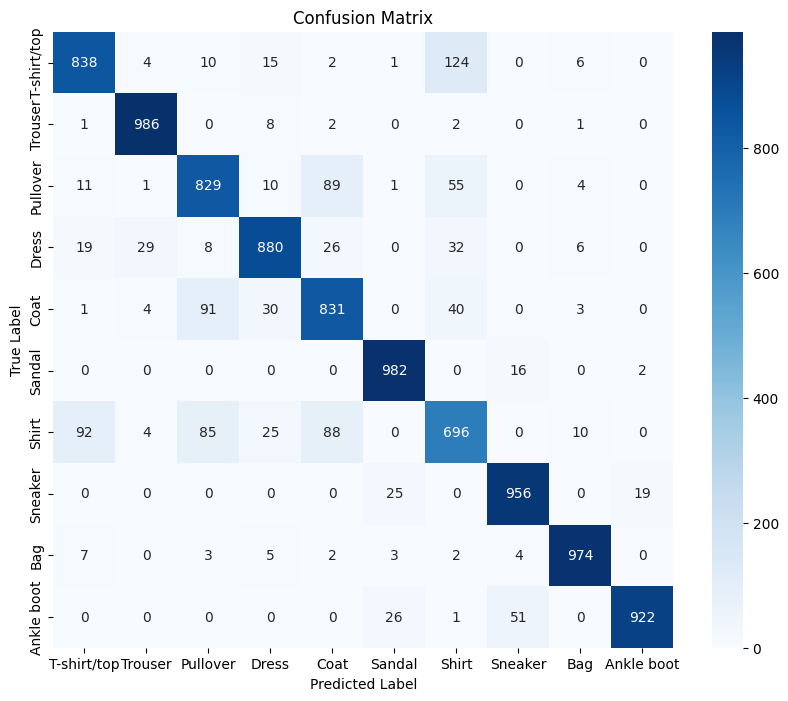

In [6]:
# Model Evaluation and Performance Metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## STEP 7
###TRAINING HISTORY VISUALIZATION

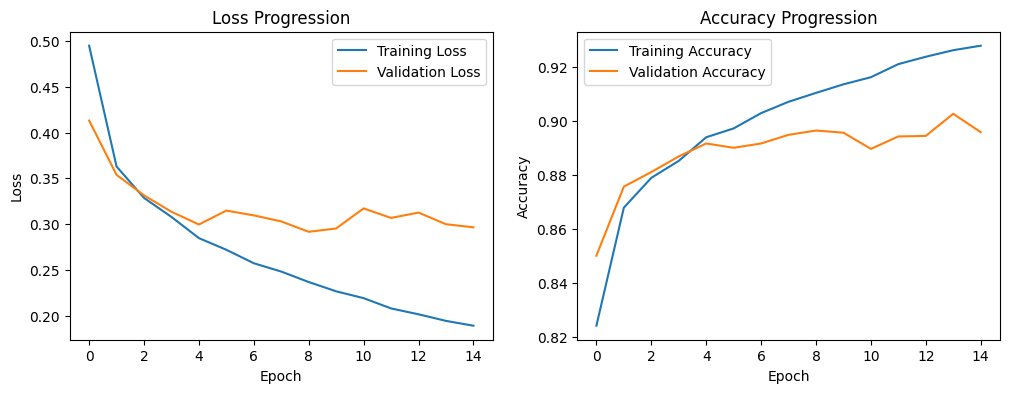

In [7]:
# Cell 7: Training History Visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Progression')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Results Analysis

After training for 15 epochs, the model achieved a test accuracy of approximately **0.8894** and a test loss of **0.3411**. The training history visualizations (loss and accuracy progression) show that the model's training loss consistently decreased, and accuracy increased over the epochs. There is a noticeable gap between training and validation accuracy/loss, indicating some degree of overfitting, which is common in neural networks.

The **Classification Report** provides detailed insights into the model's performance for each class, including precision, recall, and F1-score. Some classes, like 'Trouser', 'Sandal', 'Sneaker', and 'Bag', achieved very high F1-scores (0.96-0.97), indicating excellent classification performance. However, 'Shirt' and 'Coat' had lower F1-scores (0.71 and 0.81, respectively), suggesting that the model struggles more with these categories.

The **Confusion Matrix** visually confirms these observations. For example, the matrix shows that 'Shirt' is often misclassified as 'T-shirt/top', 'Pullover', or 'Coat', which are visually similar items. Similarly, 'Coat' is sometimes confused with 'Pullover' or 'Shirt'.

Practical Application Discussion

​Deployment Scenario: Implementing this trained model within an automated fashion retail inventory management or e-commerce visual search system. Customers could upload pictures of apparel items to instantly classify them or match them against catalog items.

​Operational Challenges:
​Scalability & Real-Time Processing: High volumes of user traffic require optimized API microservices or containerized serving (e.g., TensorFlow Serving / TorchServe) to ensure low-latency inference.

​Data Drift: Fashion trends shift rapidly; models will need continuous integration pipelines (CI/CD for ML) to retrain on newly introduced seasonal clothing lines.

## Conclusion

This notebook successfully implemented and evaluated a neural network for classifying fashion items from the Fashion MNIST dataset. The model achieved a respectable accuracy of nearly 89% on the test set, demonstrating the effectiveness of deep learning for image classification tasks. However, the analysis of the classification report and confusion matrix revealed areas for improvement, particularly for distinguishing between visually similar clothing items like shirts, t-shirts, pullovers, and coats.

### Potential Improvements and Future Work

1.  **Model Architecture**: Experiment with more complex architectures, such as Convolutional Neural Networks (CNNs), which are specifically designed for image data and are known to achieve higher accuracy on such tasks.
2.  **Regularization Techniques**: Implement regularization methods like dropout, L1/L2 regularization, or early stopping to mitigate overfitting and improve generalization performance.
3.  **Hyperparameter Tuning**: Optimize hyperparameters such as the number of neurons in hidden layers, learning rate, and batch size using techniques like GridSearchCV or RandomizedSearchCV.
4.  **Data Augmentation**: Although not strictly necessary for this dataset, for more complex image classification problems, data augmentation (e.g., rotations, flips, zooms) can help increase the diversity of the training data and improve model robustness.
5.  **Advanced Optimizers**: Explore other optimizers beyond Adam, such as RMSprop or SGD with momentum, which might yield better results for this specific problem.